# GTM Engineer Job Market Analysis (March 2026)

This notebook provides an interactive look at the GTM (Go-To-Market) Engineering job market, based on 310 high-quality technical roles extracted from Builtin.com.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Premium Aesthetics
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="muted")

# Load Structured Data
DATA_PATH = "_internal/structured_jobs.json"
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    df = pd.DataFrame(json.load(f))

# Filter for technical roles only
df_gtm = df[df["is_gtm_technical"] == True].copy()
print(f"Loaded {len(df_gtm)} GTM Technical Roles")

Loaded 310 GTM Technical Roles


## 1. Top GTM Engineering Tools
Which tools are most frequently requested in GTM Engineering roles?

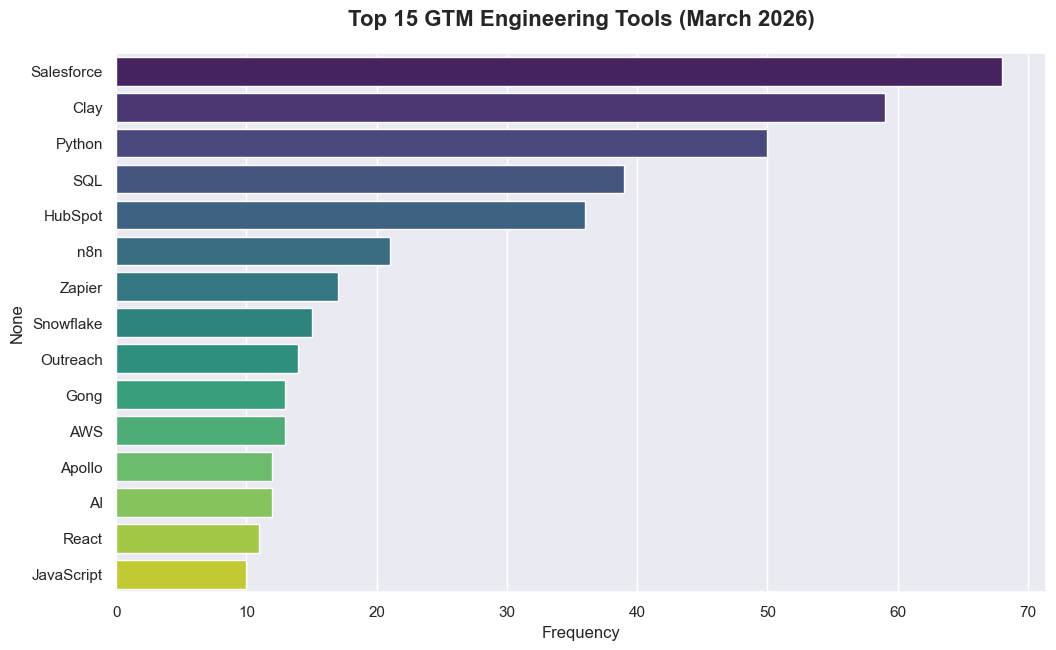

In [4]:
all_tools = []
for tools in df_gtm["tech_stack"].dropna():
    if isinstance(tools, list): all_tools.extend(tools)

tool_counts = pd.Series(all_tools).value_counts().head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=tool_counts.values, y=tool_counts.index, hue=tool_counts.index, palette="viridis", legend=False)
plt.title("Top 15 GTM Engineering Tools (March 2026)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Frequency")
plt.show()

## 2. Salary Analysis by Seniority
Distribution of annual base salary ranges (USD).

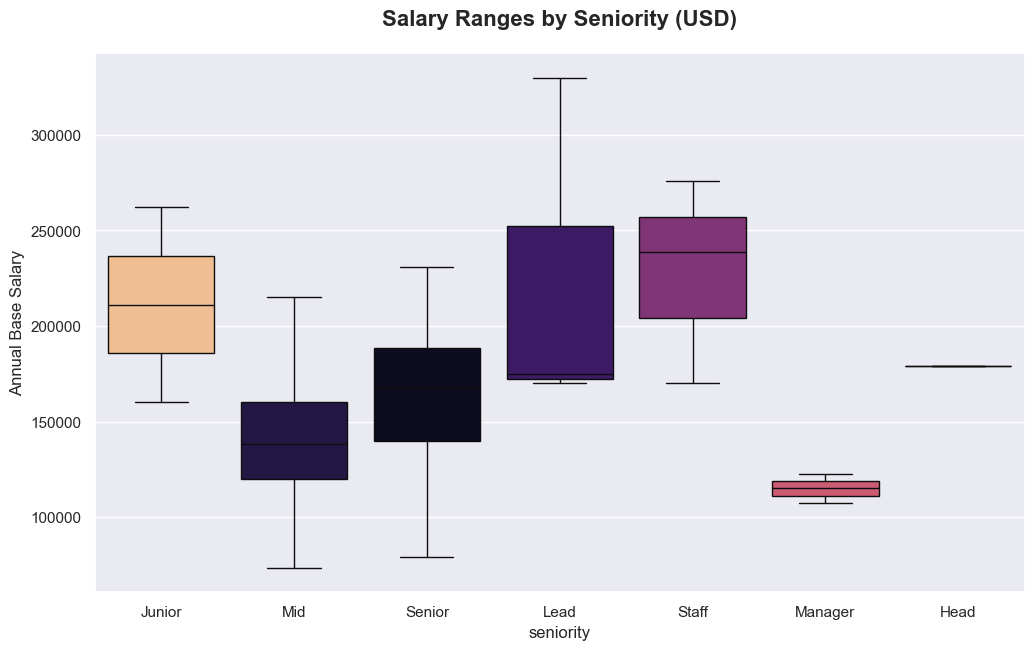

In [5]:
df_gtm["salary_min"] = pd.to_numeric(df_gtm["salary_min"], errors='coerce')
df_gtm["salary_max"] = pd.to_numeric(df_gtm["salary_max"], errors='coerce')
sal_df = df_gtm.dropna(subset=["salary_min", "salary_max", "seniority"])
sal_df = sal_df[sal_df["salary_min"] > 0]
sal_df["avg_salary"] = (sal_df["salary_min"] + sal_df["salary_max"]) / 2

order = ["Junior", "Mid", "Senior", "Lead", "Staff", "Manager", "Head"]
current_order = [o for o in order if o in sal_df["seniority"].unique()]

plt.figure(figsize=(12, 7))
sns.boxplot(data=sal_df, x="seniority", y="avg_salary", order=current_order, hue="seniority", palette="magma", legend=False)
plt.title("Salary Ranges by Seniority (USD)", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Annual Base Salary")
plt.show()